In [1]:
# %%
import os
import sys
import json

# 设置路径
project_root = os.path.abspath("..")
sys.path.append(project_root)

from src.model_utils import load_model_and_tokenizer
from src.remove_test import (compute_layer_cos_sims, 
                                run_layerwise_remove_test, 
                                plot_remove_test, 
                                save_layerwise_results,
                                load_layerwise_results,
                                fit_logistic_curves,
                                plot_fitted_curves,
                                )

In [2]:
# 模型 & 数据配置
MODEL_NAME = "Llama-2-13b-hf"
MODEL_ROOT = "/mnt/public/model/huggingface/"
MODEL_PATH = os.path.join(MODEL_ROOT, MODEL_NAME)
OUTPUT_DIR = os.path.abspath("../layer_importance")
os.makedirs(OUTPUT_DIR, exist_ok=True)

TEXT_LIST = [
    "The Pythagorean theorem states that the square of the hypotenuse is equal to the sum of the squares of the other two sides.",
    "In Python, you can define a function using the def keyword followed by the function name and parentheses.",
    "Water boils at 100 degrees Celsius under standard atmospheric pressure.",
    "The Earth revolves around the Sun in approximately 365.25 days.",
    "The mitochondrion is often referred to as the powerhouse of the cell because it generates most of the cell's energy."
]

PRUNE_RATIOS = [i / 100 for i in range(10, 101, 10)]
USE_SOFTMASK = True
RESULTS_SAVE_PATH = "remove_test_results.npy"

In [3]:
# 模型加载
model, tokenizer = load_model_and_tokenizer(MODEL_PATH)
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token

/opt/conda/lib/python3.10/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/opt/conda/lib/python3.10/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https:/

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [4]:
# 计算隐藏状态相似度（变化量）
layer_cos_sims = compute_layer_cos_sims(model, tokenizer, TEXT_LIST)
print("\n=== Layer-wise Input/Output Cosine Similarities ===")
for i, sim in enumerate(layer_cos_sims):
    print(f"Layer {i:02d}: {sim:.4f}")


=== Layer-wise Input/Output Cosine Similarities ===
Layer 00: 0.0304
Layer 01: 0.9995
Layer 02: 1.0000
Layer 03: 0.7466
Layer 04: 0.9614
Layer 05: 0.9644
Layer 06: 0.9678
Layer 07: 0.9229
Layer 08: 0.9609
Layer 09: 0.9673
Layer 10: 0.9688
Layer 11: 0.9722
Layer 12: 0.9766
Layer 13: 0.9785
Layer 14: 0.9731
Layer 15: 0.9805
Layer 16: 0.9795
Layer 17: 0.9844
Layer 18: 0.9868
Layer 19: 0.9888
Layer 20: 0.9829
Layer 21: 0.9897
Layer 22: 0.9888
Layer 23: 0.9932
Layer 24: 0.9951
Layer 25: 0.9941
Layer 26: 0.9946
Layer 27: 0.9966
Layer 28: 0.9956
Layer 29: 0.9961
Layer 30: 0.9966
Layer 31: 0.9966
Layer 32: 0.9966
Layer 33: 0.9961
Layer 34: 0.9951
Layer 35: 0.9941
Layer 36: 0.9922
Layer 37: 0.9443
Layer 38: 0.9604
Layer 39: 0.2566


In [5]:
# 执行剪枝保留度测试
remove_results = run_layerwise_remove_test(
    model, tokenizer,
    text_list=TEXT_LIST,
    prune_ratios=PRUNE_RATIOS,
    use_softmask=USE_SOFTMASK
)

The attention layers in this model are transitioning from computing the RoPE embeddings internally through `position_ids` (2D tensor with the indexes of the tokens), to using externally computed `position_embeddings` (Tuple of tensors, containing cos and sin). In v4.46 `position_ids` will be removed and `position_embeddings` will be mandatory.



=== Remove Test for Layer 0 ===
[Layer 0 | Ratio=0.1] CosSim = 0.0086 | Kept heads: 36, MLP: 12441
[Layer 0 | Ratio=0.2] CosSim = -0.0008 | Kept heads: 32, MLP: 11059
[Layer 0 | Ratio=0.3] CosSim = -0.0071 | Kept heads: 28, MLP: 9676
[Layer 0 | Ratio=0.4] CosSim = -0.0974 | Kept heads: 24, MLP: 8294
[Layer 0 | Ratio=0.5] CosSim = -0.1091 | Kept heads: 20, MLP: 6912
[Layer 0 | Ratio=0.6] CosSim = -0.1099 | Kept heads: 16, MLP: 5529
[Layer 0 | Ratio=0.7] CosSim = -0.1317 | Kept heads: 12, MLP: 4147
[Layer 0 | Ratio=0.8] CosSim = -0.1328 | Kept heads: 7, MLP: 2764
[Layer 0 | Ratio=0.9] CosSim = -0.1309 | Kept heads: 3, MLP: 1382
[Layer 0 | Ratio=1.0] CosSim = 0.1069 | Kept heads: 0, MLP: 0

=== Remove Test for Layer 1 ===
[Layer 1 | Ratio=0.1] CosSim = 0.8306 | Kept heads: 36, MLP: 12441
[Layer 1 | Ratio=0.2] CosSim = 0.8389 | Kept heads: 32, MLP: 11059
[Layer 1 | Ratio=0.3] CosSim = 0.8477 | Kept heads: 28, MLP: 9676
[Layer 1 | Ratio=0.4] CosSim = 0.8691 | Kept heads: 24, MLP: 8294
[Lay

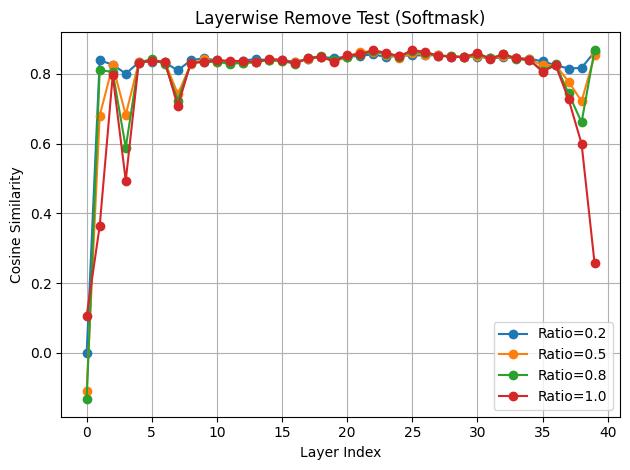

In [6]:
# 可视化不同剪枝比例的相似度
plot_remove_test(remove_results, ratios_to_plot=[0.2, 0.5, 0.8, 1.0])

In [7]:
fitted_result = fit_logistic_curves(
    remove_results=remove_results,
    protect_head_layers=2,
    protect_tail_layers=2,
    outlier_method="iqr",
    outlier_threshold=1.5
)

[✓] Logistic Fit: a=0.0036, b=-1.6054
[✓] Linear Fit: y = 0.0005 * x + 0.8332


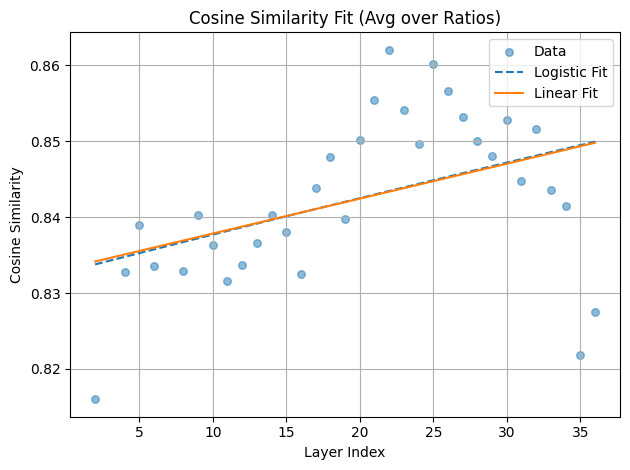

In [8]:
plot_fitted_curves(
    fitted_result,
    show_data=True,
    show_logistic=True,
    show_linear=True,
    title="Cosine Similarity Fit (Avg over Ratios)"
)


In [9]:
# 保存
save_layerwise_results(
    model_name=MODEL_NAME,
    cos_sims=layer_cos_sims,
    remove_results=remove_results,
    fitted_result=fitted_result
)


[✓] Saved all data under: /mnt/public/code/hanyu/codes/SEAP/layer_importance/Llama-2-13b-hf


In [10]:
# 加载
model_name, cos_sims, remove_results, fitted_result = load_layerwise_results(MODEL_NAME)
print("Loaded model:", model_name)


[✓] Loaded layerwise results for model: Llama-2-13b-hf
Loaded model: Llama-2-13b-hf
